# 20 日收益率动量因子回测

## tl;dr

本次已执行样本覆盖 2020-01-02 至 2026-07-31，共 1,594 个交易日、7,553,382 条股票日记录。20 日动量的 1/3/5 日 RankIC 分别为 -0.0336、-0.0407、-0.0459；G5-G1 年化多空收益分别为 -3.79%、-10.37%、-11.70%，最高动量组没有表现出动量延续，反而呈现短期反转，G3/G4 的净值长期更好。因子与未来收益的程序口径检查通过，但这仍是带有同收盘成交、动态股票池和无交易成本假设的理论因子研究，不能直接视为可交易策略收益。

## Context & Methods

目标是检验 A 股过去 20 个交易日收益率动量对未来 1、3、5 个交易日收益的截面解释能力。

因子定义为：$Momentum_{20,t}=\prod_{k=0}^{19}(1+r_{t-k})-1$，其中 $r_t=close_t/pre\_close_t-1$。因子包含截至 t 日收盘已经实现的收益；`analyze_factor` 从 t+1 日收益开始评价，避免把 t 日收益同时放入因子和未来收益。

### Key Assumptions

- 分析区间为 2020-01-01 至 2026-08-01，额外向前读取 60 个自然日作为 20 个交易日窗口的预热期。
- 与原模板一致，每日以 `total_mv` 做一次线性总市值中性化，G1 为因子最低组、G5 为因子最高组。
- benchmark 是当日有效股票池的等权收益，不是沪深 300 等可交易指数。
- 本结果是因子研究口径：不含手续费、滑点、涨跌停成交约束和真实资金容量。

In [1]:
# 统一参数和依赖；使用项目约定的 quant 内核执行。
import datetime as dt
import sys
from pathlib import Path

import numpy as np
import polars as pl
from IPython.display import display

project_root = Path(r"C:\Users\20561\Desktop\策略")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from my_utils.fun import read_day_data
from 因子回测.alpha import analyze_factor, ols_neutralize

analysis_start_date = dt.date(2020, 1, 1)
analysis_end_date = dt.date(2026, 8, 1)
warmup_calendar_days = 60
load_start_date = analysis_start_date - dt.timedelta(days=warmup_calendar_days)
momentum_window = 20
ret_windows = [1, 3, 5]
ic_windows = [1, 3, 5]
group_num = 5

## Data

从项目本地 `rq_stock_all_data` Parquet 数据集读取日线。只在原模板所需字段完整时保留记录；ST、停牌和上市不足 20 个交易日的股票不会预先删除，以便先复现模板口径，再在诊断和结论中明确其影响。

In [2]:
def profile_stock_daily_source(data: pl.DataFrame) -> pl.DataFrame:
    """汇总股票日线源数据的主键、日期和核心字段完整性。"""
    core_fields = [
        "open",
        "close",
        "pre_close",
        "limit_up",
        "limit_down",
        "total_mv",
    ]
    required = {"trading_date", "code", *core_fields}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError("缺少必要列: " + ", ".join(missing))

    return data.select(
        pl.len().alias("rows"),
        pl.col("trading_date").min().alias("date_min"),
        pl.col("trading_date").max().alias("date_max"),
        pl.col("code").n_unique().alias("stocks"),
        pl.struct(["trading_date", "code"])
        .is_duplicated()
        .sum()
        .alias("duplicate_key_rows"),
        *[pl.col(column).null_count().alias(f"{column}_nulls") for column in core_fields],
    )


# 读取预热期与正式评价期数据。预热数据只参与因子计算，不进入回测统计。
required_fields = [
    "code",
    "name",
    "trading_date",
    "open",
    "close",
    "pre_close",
    "pct",
    "limit_up",
    "limit_down",
    "is_st",
    "is_suspended",
    "adj_factor",
    "total_mv",
]
raw_stock_data = read_day_data(
    start_date=load_start_date,
    end_date=analysis_end_date,
    fields=required_fields,
)
source_quality_summary = profile_stock_daily_source(raw_stock_data)
stock_data = raw_stock_data.drop_nulls(
    subset=["open", "close", "pre_close", "limit_up", "limit_down", "total_mv"]
)
del raw_stock_data

print(
    f"读取 {stock_data.height:,} 行，"
    f"日期范围 {stock_data['trading_date'].min()} 至 {stock_data['trading_date'].max()}"
)
stock_data.head()

读取 7,742,499 行，日期范围 2019-11-04 至 2026-07-31


code,name,trading_date,open,close,pre_close,pct,limit_up,limit_down,is_st,is_suspended,adj_factor,total_mv
str,str,date,f64,f64,f64,f64,f64,f64,bool,bool,f64,f64
"""SHSE.600000""","""浦发银行""",2019-11-04,12.75,12.74,12.75,-0.078431,14.03,11.48,false,false,12.7227,3.7395e11
"""SHSE.600004""","""白云机场""",2019-11-04,18.01,18.58,18.11,2.595251,19.92,16.3,false,false,2.58093,3.8448e10
"""SHSE.600006""","""东风股份""",2019-11-04,4.44,4.44,4.44,0.0,4.88,4.0,false,false,3.61972,8.8800e9
"""SHSE.600007""","""中国国贸""",2019-11-04,17.67,17.66,17.67,-0.056593,19.44,15.9,false,false,1.76151,1.7789e10
"""SHSE.600008""","""首创环保""",2019-11-04,3.34,3.35,3.34,0.299401,3.67,3.01,false,false,7.63099,1.9046e10


## Factor Construction

先按股票和日期排序，再从 `close / pre_close - 1` 得到小数制单日收益。20 日收益采用 `log1p → rolling_sum → expm1`，与 20 期简单收益逐项复利等价，且不会把不同股票的数据串在同一个窗口。

In [3]:
def add_momentum_20d_factor(data: pl.DataFrame, window: int = 20) -> pl.DataFrame:
    """按股票追加单日收益和过去 window 期复权收益动量。

    `daily_ret[t]` 使用当日 close/pre_close；滚动窗口只包含截至 t 日的
    已实现收益。首个完整窗口之前返回 null，防止把短历史误当 20 日样本。
    """
    required = {"code", "trading_date", "close", "pre_close"}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError("缺少必要列: " + ", ".join(missing))
    if window < 1:
        raise ValueError("window 必须是正整数")

    factor_col = f"momentum_{window}d"
    return (
        data.sort(["code", "trading_date"])
        .with_columns(
            (pl.col("close") / pl.col("pre_close") - 1).alias("daily_ret")
        )
        .with_columns(
            (
                (1 + pl.col("daily_ret"))
                .log()
                .rolling_sum(window)
                .over("code")
                .exp()
                - 1
            ).alias(factor_col)
        )
    )


stock_data = add_momentum_20d_factor(stock_data, window=momentum_window)
factor_col = f"momentum_{momentum_window}d"

# 预热完成后再截取正式分析区间，并排除不可用于排序或收益评价的非有限值。
evaluation_stock_data = (
    stock_data.filter(
        pl.col("trading_date").is_between(analysis_start_date, analysis_end_date)
    )
    .drop_nulls([factor_col, "daily_ret", "total_mv"])
    .filter(
        pl.col(factor_col).is_finite()
        & pl.col("daily_ret").is_finite()
        & pl.col("total_mv").is_finite()
    )
)

# 与原模板一致：每日截面以总市值做 OLS 中性化，残差作为最终排序因子。
evaluation_stock_data = (
    evaluation_stock_data.group_by("trading_date", maintain_order=True)
    .map_groups(
        lambda frame: ols_neutralize(
            frame,
            y_column=factor_col,
            x_columns=["total_mv"],
        )
    )
    .sort(["trading_date", "code"])
)
neutralized_factor_col = f"{factor_col}_neutralized"

# benchmark 只使用最终有效因子样本，保证与各分组处在同一动态股票池。
analysis_data = (
    evaluation_stock_data.drop_nulls([neutralized_factor_col])
    .filter(pl.col(neutralized_factor_col).is_finite())
    .with_columns(
        pl.col("daily_ret").mean().over("trading_date").alias("benchmark_ret")
    )
    .select(
        "trading_date",
        "code",
        "name",
        factor_col,
        neutralized_factor_col,
        "daily_ret",
        "benchmark_ret",
        "total_mv",
        "is_st",
        "is_suspended",
    )
)

analysis_data.head()

trading_date,code,name,momentum_20d,momentum_20d_neutralized,daily_ret,benchmark_ret,total_mv,is_st,is_suspended
date,str,str,f64,f64,f64,f64,f64,bool,bool
2020-01-02,"""SHSE.600000""","""浦发银行""",0.061277,-0.024515,0.008084,0.018269,3.6602e11,false,false
2020-01-02,"""SHSE.600004""","""白云机场""",0.025761,-0.068122,0.004011,0.018269,3.6254e10,false,false
2020-01-02,"""SHSE.600006""","""东风股份""",0.040268,-0.054276,0.015284,0.018269,9.3000e9,false,false
2020-01-02,"""SHSE.600007""","""中国国贸""",0.054687,-0.039651,0.002857,0.018269,1.7678e10,false,false
2020-01-02,"""SHSE.600008""","""首创环保""",0.024615,-0.069692,0.012158,0.018269,1.8933e10,false,false


## Validation Checks

这些检查分别验证源数据主键与完整性、收益单位、复权处理、股票池覆盖、中性化残差和未来收益日期对齐。尤其关注直接使用原始收盘价计算 20 日收益会造成多大偏差，以及个股缺行是否会让 IC 的‘未来 N 日’跨过更多市场交易日。

In [4]:
def audit_forward_horizon_alignment(
    data: pl.DataFrame, horizons=(1, 3, 5)
) -> pl.DataFrame:
    """检查按股票 shift(-N) 是否与市场第 N 个后续交易日对齐。

    `analyze_factor` 的 IC 收益按个股记录移动；若某只股票在市场日历中缺行，
    下一条个股记录可能跨过多个市场交易日。本函数量化这种口径风险。
    """
    required = {"trading_date", "code"}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError("缺少必要列: " + ", ".join(missing))

    sorted_data = (
        data.select("trading_date", "code")
        .unique()
        .sort(["code", "trading_date"])
    )
    market_calendar = (
        sorted_data.select("trading_date").unique().sort("trading_date")
    )
    results = []

    for horizon in horizons:
        if horizon < 1:
            raise ValueError("horizons 必须全部为正整数")
        expected_dates = market_calendar.with_columns(
            pl.col("trading_date")
            .shift(-horizon)
            .alias("expected_future_date")
        )
        comparable = (
            sorted_data.with_columns(
                pl.col("trading_date")
                .shift(-horizon)
                .over("code")
                .alias("actual_future_date")
            )
            .join(expected_dates, on="trading_date", how="left")
            .drop_nulls(["actual_future_date", "expected_future_date"])
        )
        comparable_pairs = comparable.height
        misaligned_pairs = comparable.filter(
            pl.col("actual_future_date") != pl.col("expected_future_date")
        ).height
        results.append(
            {
                "window": horizon,
                "comparable_pairs": comparable_pairs,
                "misaligned_pairs": misaligned_pairs,
                "misaligned_ratio": (
                    misaligned_pairs / comparable_pairs if comparable_pairs else None
                ),
            }
        )

    return pl.DataFrame(results).sort("window")


# 1. 本地 pct 字段以百分数存储；close/pre_close-1 应与 pct/100 完全对齐。
return_scale_check = stock_data.select(
    (pl.col("daily_ret") - pl.col("pct") / 100)
    .abs()
    .max()
    .alias("daily_ret_vs_pct_div_100_max_abs_diff")
)

# 2. 与未经复权的原始收盘价比值比较，量化除权除息带来的错误幅度。
raw_close_comparison = (
    stock_data.with_columns(
        (
            pl.col("close") / pl.col("close").shift(momentum_window).over("code")
            - 1
        ).alias("momentum_20d_raw_close"),
        pl.col("adj_factor").shift(momentum_window).over("code").alias(
            "adj_factor_lag20"
        ),
    )
    .filter(
        pl.col("trading_date").is_between(analysis_start_date, analysis_end_date)
    )
    .drop_nulls([factor_col, "momentum_20d_raw_close", "adj_factor_lag20"])
    .select(
        (pl.col(factor_col) - pl.col("momentum_20d_raw_close"))
        .abs()
        .mean()
        .alias("mean_abs_diff"),
        (pl.col(factor_col) - pl.col("momentum_20d_raw_close"))
        .abs()
        .quantile(0.99)
        .alias("p99_abs_diff"),
        (pl.col(factor_col) - pl.col("momentum_20d_raw_close"))
        .abs()
        .max()
        .alias("max_abs_diff"),
        (pl.col("adj_factor") != pl.col("adj_factor_lag20"))
        .mean()
        .alias("adj_factor_changed_ratio"),
    )
)

# 3. 样本和因子分布；极端动量通常与新股或重大公司行为有关。
sample_summary = analysis_data.select(
    pl.len().alias("rows"),
    pl.col("trading_date").n_unique().alias("trading_days"),
    pl.col("code").n_unique().alias("stocks"),
    pl.col(factor_col).min().alias("factor_min"),
    pl.col(factor_col).quantile(0.01).alias("factor_p01"),
    pl.col(factor_col).median().alias("factor_median"),
    pl.col(factor_col).quantile(0.99).alias("factor_p99"),
    pl.col(factor_col).max().alias("factor_max"),
    pl.col("is_st").mean().alias("st_row_ratio"),
    pl.col("is_suspended").mean().alias("suspended_row_ratio"),
)
daily_sample_count = (
    analysis_data.group_by("trading_date").len().select(
        pl.col("len").min().alias("daily_stock_count_min"),
        pl.col("len").median().alias("daily_stock_count_median"),
        pl.col("len").max().alias("daily_stock_count_max"),
    )
)

# 4. OLS 残差在每日截面上应接近零均值，并与 total_mv 接近零相关。
neutralization_check = (
    analysis_data.group_by("trading_date").agg(
        pl.col(neutralized_factor_col).mean().alias("residual_mean"),
        pl.corr(neutralized_factor_col, "total_mv").alias("residual_mv_corr"),
    )
    .select(
        pl.col("residual_mean").abs().max().alias("max_abs_daily_residual_mean"),
        pl.col("residual_mv_corr").abs().max().alias("max_abs_daily_residual_mv_corr"),
    )
)

# 5. IC 未来收益的 shift(-N) 应尽量对应市场日历第 N 个后续交易日。
forward_alignment_check = audit_forward_horizon_alignment(
    analysis_data.select("trading_date", "code"), horizons=ic_windows
)

display(source_quality_summary)
display(return_scale_check)
display(raw_close_comparison)
display(sample_summary)
display(daily_sample_count)
display(neutralization_check)
display(forward_alignment_check)

rows,date_min,date_max,stocks,duplicate_key_rows,open_nulls,close_nulls,pre_close_nulls,limit_up_nulls,limit_down_nulls,total_mv_nulls
u32,date,date,u32,u32,u32,u32,u32,u32,u32,u32
7742499,2019-11-04,2026-07-31,5736,0,0,0,0,0,0,0


daily_ret_vs_pct_div_100_max_abs_diff
f64
8.8818e-16


mean_abs_diff,p99_abs_diff,max_abs_diff,adj_factor_changed_ratio
f64,f64,f64,f64
0.003052,0.045082,1.306669,0.068249


rows,trading_days,stocks,factor_min,factor_p01,factor_median,factor_p99,factor_max,st_row_ratio,suspended_row_ratio
u32,u32,u32,f64,f64,f64,f64,f64,f64,f64
7553382,1594,5423,-0.965447,-0.284618,-0.004171,0.506118,20.730337,0.035037,0.003053


daily_stock_count_min,daily_stock_count_median,daily_stock_count_max
u32,f64,u32
3741,4938.5,5205


max_abs_daily_residual_mean,max_abs_daily_residual_mv_corr
f64,f64
2.9095e-16,3.7331e-16


window,comparable_pairs,misaligned_pairs,misaligned_ratio
i64,i64,i64,f64
1,7547959,0,0.0
3,7537113,0,0.0
5,7526271,0,0.0


## Results

`ret_windows` 表示分组调仓间隔，调仓日的分组用于之后 1/3/5 个交易日的逐日收益；`ic_windows` 表示因子与未来累计 1/3/5 日收益的相关窗口。

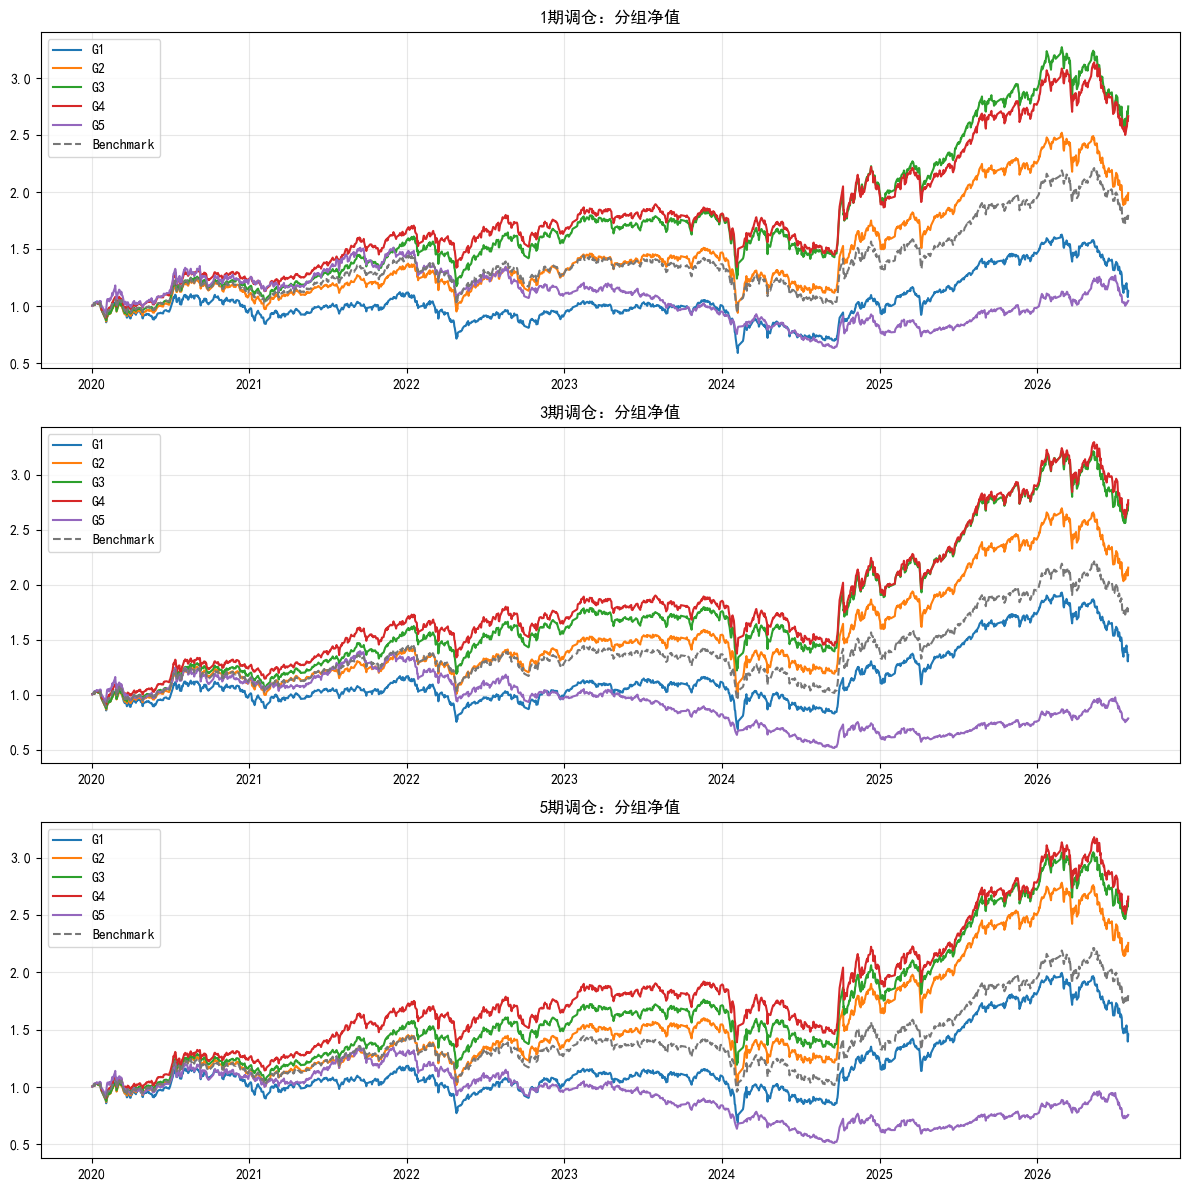

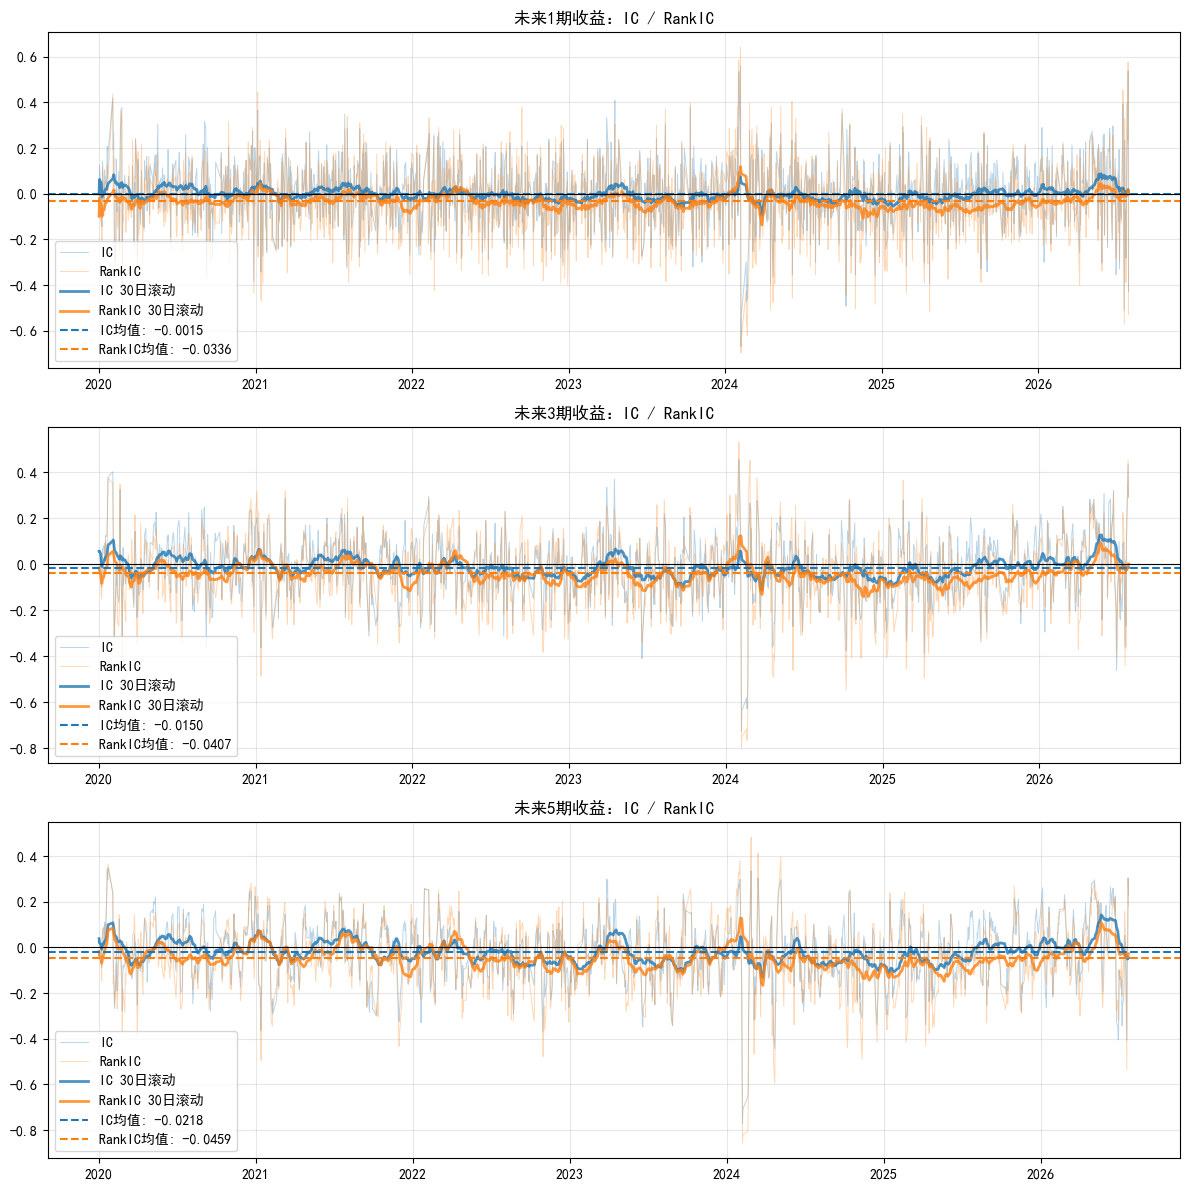

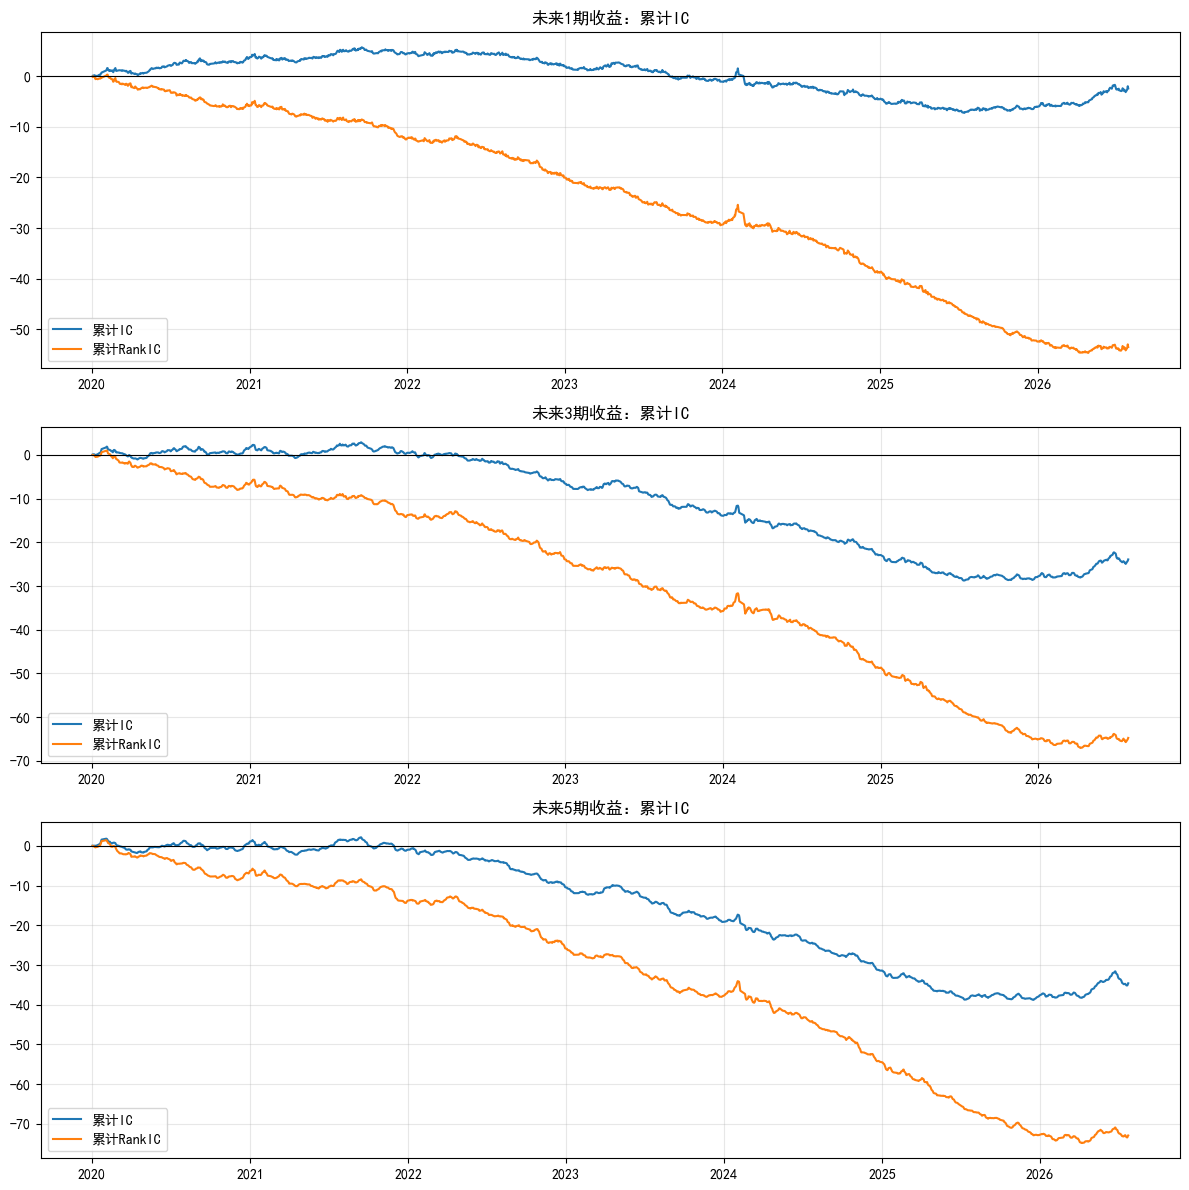

因子一阶截面秩自相关: 0.928645


window,ic_mean,ic_std,ic_positive_ratio,rank_ic_mean,rank_ic_std,rank_ic_positive_ratio,ic_ir,rank_ic_ir
i32,f64,f64,f64,f64,f64,f64,f64,f64
1,-0.001513,0.141162,0.502825,-0.03361,0.162158,0.404269,-0.010719,-0.207268
3,-0.015042,0.132355,0.468259,-0.040708,0.151242,0.396606,-0.113646,-0.269159
5,-0.021773,0.128401,0.444305,-0.045886,0.146322,0.365639,-0.169571,-0.313597


window,group,mean_return,annual_return,sharpe,max_drawdown,positive_ratio
i32,str,f64,f64,f64,f64,f64
1,"""G1""",0.000231,0.0196,0.209974,-0.474671,0.530446
1,"""G2""",0.000557,0.115265,0.56364,-0.377188,0.543001
1,"""G3""",0.000746,0.173655,0.799681,-0.325293,0.554928
1,"""G4""",0.000722,0.167847,0.789258,-0.290461,0.55995
1,"""G5""",0.000157,0.007227,0.155586,-0.581753,0.531701
…,…,…,…,…,…,…
5,"""G1""",0.000383,0.061507,0.357037,-0.422313,0.536095
5,"""G2""",0.000632,0.137425,0.647522,-0.365816,0.544884
5,"""G3""",0.000718,0.165855,0.774938,-0.322256,0.562461


In [5]:
result = analyze_factor(
    data=analysis_data.select(
        "trading_date",
        "code",
        neutralized_factor_col,
        "daily_ret",
        "benchmark_ret",
    ),
    factor_col=neutralized_factor_col,
    ret_col="daily_ret",
    ret_windows=ret_windows,
    ic_windows=ic_windows,
    group_num=group_num,
    plot=True,
    save_result=False,
)

print(f"因子一阶截面秩自相关: {result['factor_autocorr']:.6f}")
display(result["ic_stats"])
display(result["group_stats"])

In [6]:
# 单独构造 G5-G1 日收益，避免把两个分组各自 CAGR 直接相减后误称多空收益。
spread_returns = (
    result["group_returns"]
    .filter(pl.col("group").is_in(["G1", "G5"]))
    .select("trading_date", "window", "group", "return")
    .pivot(on="group", index=["trading_date", "window"], values="return")
    .drop_nulls(["G1", "G5"])
    .with_columns((pl.col("G5") - pl.col("G1")).alias("spread_return"))
    .sort(["window", "trading_date"])
    .with_columns(
        (1 + pl.col("spread_return"))
        .cum_prod()
        .over("window")
        .alias("spread_nav")
    )
    .with_columns(
        (
            pl.col("spread_nav")
            / pl.max_horizontal(
                pl.lit(1.0),
                pl.col("spread_nav").cum_max().over("window"),
            )
            - 1
        ).alias("spread_drawdown")
    )
)

spread_summary = (
    spread_returns.group_by("window").agg(
        pl.len().alias("days"),
        pl.col("spread_return").mean().alias("mean_daily_spread"),
        (pl.col("spread_nav").last().pow(252.0 / pl.len()) - 1).alias(
            "annualized_spread_return"
        ),
        (
            pl.col("spread_return").mean()
            / pl.col("spread_return").std()
            * np.sqrt(252)
        ).alias("spread_sharpe"),
        pl.col("spread_drawdown").min().alias("spread_max_drawdown"),
        pl.col("spread_nav").last().alias("spread_final_nav"),
    ).sort("window")
)

display(spread_summary)

window,days,mean_daily_spread,annualized_spread_return,spread_sharpe,spread_max_drawdown,spread_final_nav
i32,u32,f64,f64,f64,f64,f64
1,1593,-0.000075,-0.037873,-0.094362,-0.612434,0.783439
3,1593,-0.000362,-0.103685,-0.479527,-0.713476,0.500591
5,1593,-0.000422,-0.11704,-0.559635,-0.704583,0.455272


In [7]:
# 执行期验收：任一关键口径异常都会让 Notebook 明确失败，而不是静默产出图表。
return_scale_error = return_scale_check.item()
assert return_scale_error < 1e-12, f"daily_ret 与 pct/100 不一致: {return_scale_error}"
assert analysis_data["trading_date"].min() >= analysis_start_date
assert analysis_data["trading_date"].max() <= analysis_end_date
assert analysis_data.select(pl.col(neutralized_factor_col).is_null().sum()).item() == 0
assert set(result["ic_stats"]["window"].to_list()) == set(ic_windows)
assert result["group_stats"].height == len(ret_windows) * group_num
assert spread_summary.height == len(ret_windows)
assert set(forward_alignment_check["window"].to_list()) == set(ic_windows)
print("关键口径与结果结构检查通过。")

关键口径与结果结构检查通过。


## Takeaways

- G1 是低动量组，G5 是高动量组。本样本的 1/3/5 日 RankIC 均为负，且 G5-G1 年化收益均为负；结果不支持‘20 日高动量继续跑赢’，更接近高动量后的短期反转。G3/G4 优于两端，分组关系也不是单调直线。
- 收益单位、中性化残差和日期对齐检查通过：`daily_ret` 与 `pct/100` 的最大误差为 8.88e-16，1/3/5 日 IC 可比较样本中没有发现跨市场交易日的个股缺行错位。
- 复权处理会实质改变因子：约 6.82% 的记录在对应 20 日窗口内复权因子发生变化；若直接用原始 `close/close.shift(20)-1`，与当前复权收益动量的最大差异可达 1.3067（130.67 个百分点）。
- 因子构造和未来收益匹配没有直接前视，但存在交易时点假设：t 日收盘才能得到完整因子，而回测把 t→t+1 的收盘到收盘收益计入组合，相当于假设能在 t 日收盘成交。若信号只能盘后计算，应改用下一交易日开盘成交口径或再延迟一期。
- 股票池未排除 ST、停牌、新股和涨跌停不可成交记录；原始因子最大值达到 20.73，极端样本可能影响 OLS 中性化和最高组表现。分组回测还会在个股收益缺失时对剩余股票重新等权。
- 当前只有线性 `total_mv` 中性化，没有行业中性化，也没有使用更常见的对数市值；因此结果仍可能带有行业或非线性规模暴露。
- 动态等权 benchmark 只用于同股票池比较。若要形成可交易结论，还需要加入可交易股票池、下一开盘成交、涨跌停/停牌约束、换手率、手续费和滑点，并用真实资金框架复核。